# 02 — Preprocessing
**Health Risk Triage AI — Phase 1**

This notebook walks through the full preprocessing pipeline, showing what happens at each stage: urgency label derivation, feature engineering, imputation, scaling, and the final train/test split. It visualises the **before and after** at each step so the pipeline is auditable.

---
**Pipeline position:** `data_loading.py` → `labeling.py` → `features.py` → `preprocessing.py` → **[YOU ARE HERE]**

**Inputs:**
- `data/processed/phase1/phase1_raw.parquet` — raw vitals
- `data/processed/phase1/phase1_labeled.parquet` — after NEWS2 labeling
- `data/processed/phase1/phase1_features.parquet` — after feature engineering
- `data/processed/phase1/phase1_train.parquet` + `phase1_test.parquet` — final splits

**Output:** Observations only — no files written by this notebook

## 0. Imports and Config

In [1]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

BASE      = '../data/processed/phase1'
VITALS    = config['features']['vitals']
FEATURES  = config['features']['model_features']
TARGET    = config['features']['target']
LABELS    = ['Low', 'Medium', 'High', 'Critical']
COLORS    = ['steelblue', 'mediumseagreen', 'orange', 'tomato']

print('Config loaded.')
print(f'Model features ({len(FEATURES)}):', FEATURES)

Config loaded.
Model features (14): ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'ShockIndex', 'PulsePressure', 'NEWS2Score', 'Age', 'AgeGroup', 'Gender', 'ICULOS']


## 1. Stage Comparison — Missingness Across Pipeline Stages

Track how missingness in the key vitals changes at each pipeline stage.

Missingness (%) at each pipeline stage:
                       HR  O2Sat   SBP   DBP   MAP  Temp  Resp
Raw\n(data_loading)   8.3   12.8  15.6  47.8  10.8  64.8  11.7
Labeled\n(labeling)   8.3   12.8  15.6  47.8  10.8  64.8  11.7
Features\n(features)  8.3   12.8  15.6  16.2  10.6  64.8  11.7


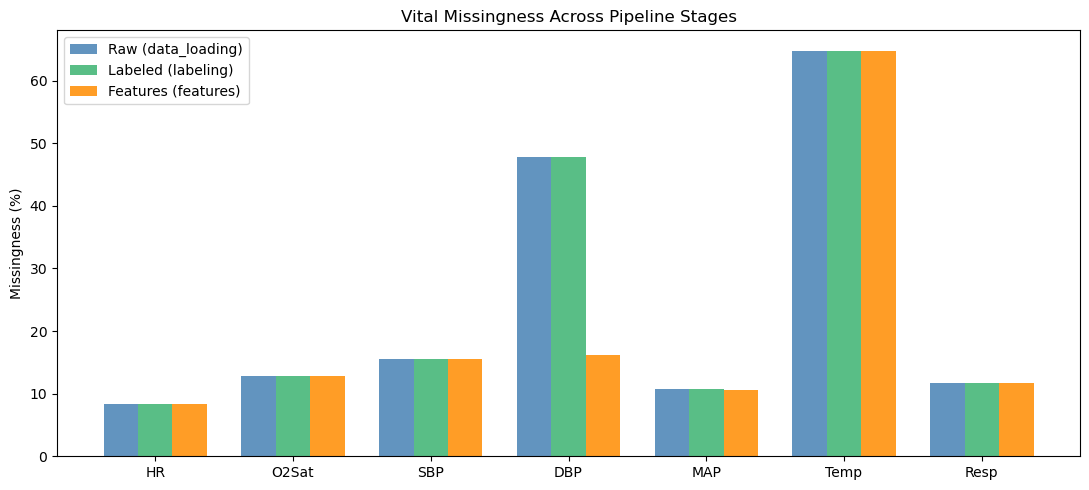


Note: DBP missingness drops from ~48% to ~16% after algebraic
recovery in features.py (DBP = (3*MAP - SBP) / 2).


In [2]:
stages = {
    'Raw\n(data_loading)' : f'{BASE}/phase1_raw.parquet',
    'Labeled\n(labeling)': f'{BASE}/phase1_labeled.parquet',
    'Features\n(features)': f'{BASE}/phase1_features.parquet',
}

track_cols = ['HR', 'O2Sat', 'SBP', 'DBP', 'MAP', 'Temp', 'Resp']
miss_by_stage = {}

for stage_name, path in stages.items():
    df_stage = pd.read_parquet(path)
    miss_by_stage[stage_name] = (
        df_stage[track_cols].isna().mean() * 100
    )

miss_df = pd.DataFrame(miss_by_stage).T
print('Missingness (%) at each pipeline stage:')
print(miss_df.round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(track_cols))
width = 0.25
stage_names = list(miss_by_stage.keys())
stage_colors = ['steelblue', 'mediumseagreen', 'darkorange']

for i, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    vals = [miss_by_stage[stage][c] for c in track_cols]
    ax.bar(x + i * width, vals, width, label=stage.replace('\n', ' '),
           color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(track_cols)
ax.set_ylabel('Missingness (%)')
ax.set_title('Vital Missingness Across Pipeline Stages')
ax.legend()
plt.tight_layout()
plt.show()

print('\nNote: DBP missingness drops from ~48% to ~16% after algebraic')
print('recovery in features.py (DBP = (3*MAP - SBP) / 2).')

## 2. Urgency Label Distribution

After `labeling.py` applies NEWS2-style scoring + SepsisLabel override.

Row-level urgency distribution:
  Low         16,877  (86.9%)
  Medium       1,661  (8.6%)
  High           392  (2.0%)
  Critical       494  (2.5%)


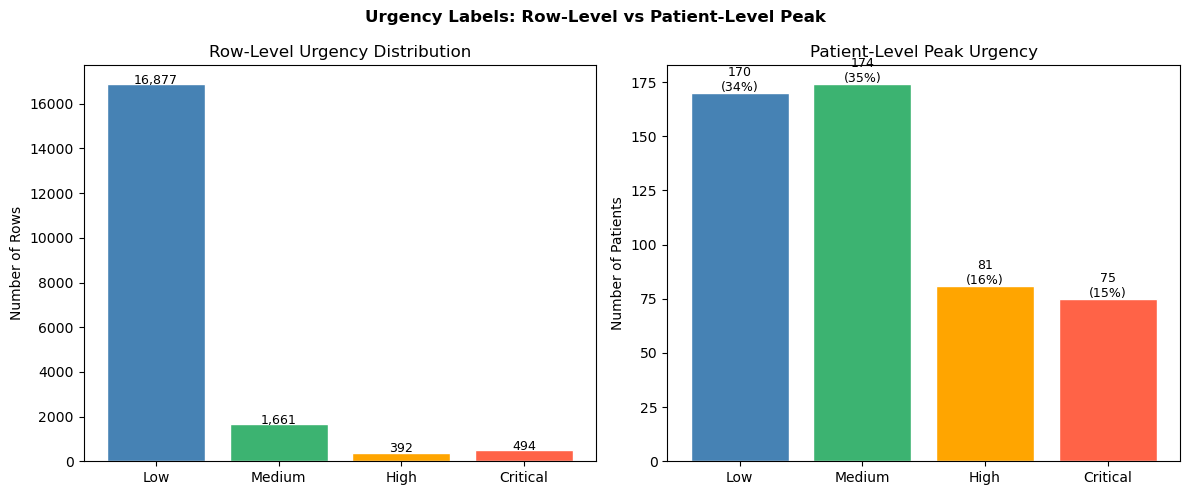


Key insight: row-level is dominated by Low (87%) because patients
spend most ICU hours stable before deteriorating.
Patient-level peak is much more balanced (34/35/16/15%).


In [3]:
df_labeled = pd.read_parquet(f'{BASE}/phase1_labeled.parquet')

# Row-level distribution
row_counts = df_labeled['UrgencyLabel'].value_counts().reindex(LABELS)
print('Row-level urgency distribution:')
for label, count in row_counts.items():
    pct = count / len(df_labeled) * 100
    print(f'  {label:<10} {count:>7,}  ({pct:.1f}%)')

# Patient-level peak urgency
peak_map  = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
rev_map   = {v: k for k, v in peak_map.items()}
df_labeled['UrgencyLevel_int'] = df_labeled['UrgencyLabel'].map(peak_map)
patient_peak = df_labeled.groupby('PatientID')['UrgencyLevel_int'].max().map(rev_map)
peak_counts  = patient_peak.value_counts().reindex(LABELS)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Row-level
axes[0].bar(LABELS, row_counts.values, color=COLORS, edgecolor='white')
axes[0].set_title('Row-Level Urgency Distribution')
axes[0].set_ylabel('Number of Rows')
for bar, val in zip(axes[0].patches, row_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=9)

# Patient-level peak
axes[1].bar(LABELS, peak_counts.values, color=COLORS, edgecolor='white')
axes[1].set_title('Patient-Level Peak Urgency')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(axes[1].patches, peak_counts.values):
    pct = val / patient_peak.shape[0] * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}\n({pct:.0f}%)', ha='center', fontsize=9)

plt.suptitle('Urgency Labels: Row-Level vs Patient-Level Peak', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey insight: row-level is dominated by Low (87%) because patients')
print('spend most ICU hours stable before deteriorating.')
print('Patient-level peak is much more balanced (34/35/16/15%).')

## 3. NEWS2Score Distribution by Urgency Level

Validates that the NEWS2-to-urgency mapping is working correctly — each urgency band should cluster at its expected score range.

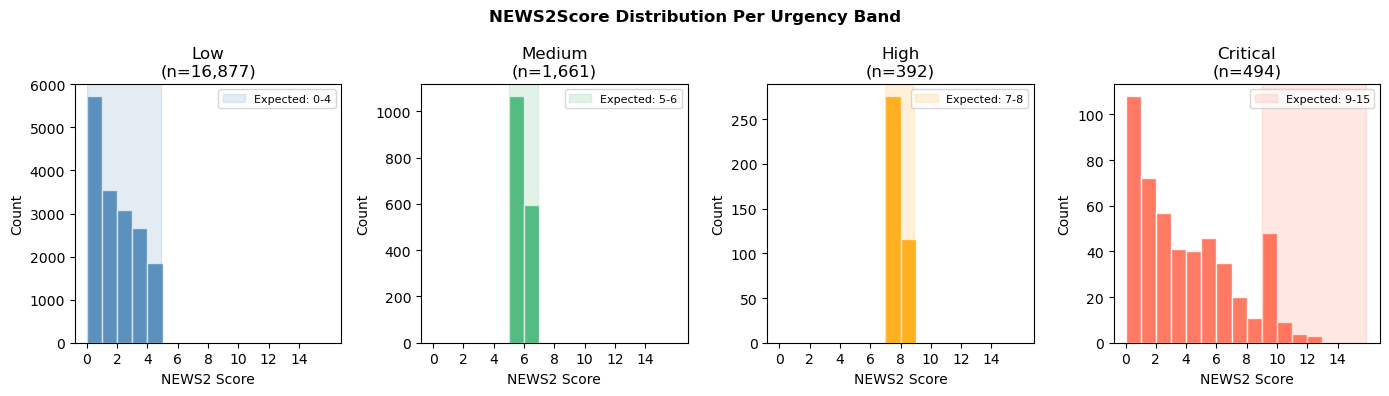

Note: Critical band contains rows with NEWS2Score < 9.
These are SepsisLabel=1 overrides — sepsis-driven Critical
cases where vitals alone did not yet score high enough.


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, label, color in zip(axes, LABELS, COLORS):
    subset = df_labeled[df_labeled['UrgencyLabel'] == label]['NEWS2Score']
    ax.hist(subset, bins=range(0, 17), color=color,
            edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\n(n={len(subset):,})')
    ax.set_xlabel('NEWS2 Score')
    ax.set_ylabel('Count')
    ax.set_xticks(range(0, 16, 2))

    # Shade expected score range per band
    bands = config['labeling']['urgency_bands']
    lo, hi = bands.get(label, [0, 15])
    ax.axvspan(lo, hi + 0.9, alpha=0.15, color=color, label=f'Expected: {lo}-{hi}')
    ax.legend(fontsize=8)

plt.suptitle('NEWS2Score Distribution Per Urgency Band', fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: Critical band contains rows with NEWS2Score < 9.')
print('These are SepsisLabel=1 overrides — sepsis-driven Critical')
print('cases where vitals alone did not yet score high enough.')

## 4. Engineered Features

Visualise the three new features added by `features.py`: ShockIndex, PulsePressure, and AgeGroup.

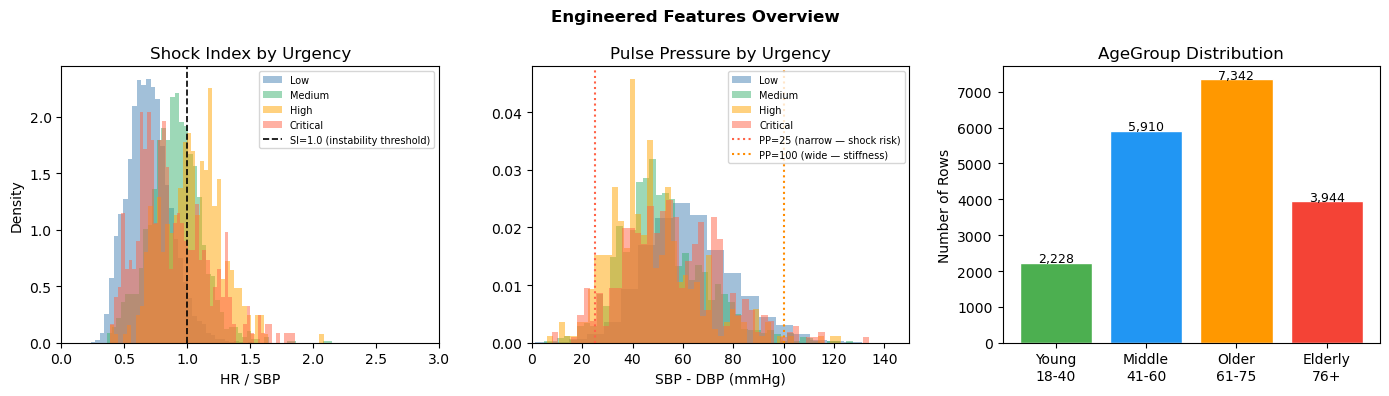

In [5]:
df_feat = pd.read_parquet(f'{BASE}/phase1_features.parquet')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Shock Index — by urgency level
for label, color in zip(LABELS, COLORS):
    vals = df_feat[df_feat['UrgencyLabel'] == label]['ShockIndex'].dropna()
    axes[0].hist(vals, bins=50, alpha=0.5, density=True,
                 color=color, label=label)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.2,
                label='SI=1.0 (instability threshold)')
axes[0].set_title('Shock Index by Urgency')
axes[0].set_xlabel('HR / SBP')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7)
axes[0].set_xlim(0, 3)

# Pulse Pressure — by urgency level
for label, color in zip(LABELS, COLORS):
    vals = df_feat[df_feat['UrgencyLabel'] == label]['PulsePressure'].dropna()
    axes[1].hist(vals, bins=50, alpha=0.5, density=True,
                 color=color, label=label)
axes[1].axvline(25,  color='tomato',    linestyle=':', label='PP=25 (narrow — shock risk)')
axes[1].axvline(100, color='darkorange', linestyle=':', label='PP=100 (wide — stiffness)')
axes[1].set_title('Pulse Pressure by Urgency')
axes[1].set_xlabel('SBP - DBP (mmHg)')
axes[1].legend(fontsize=7)
axes[1].set_xlim(0, 150)

# AgeGroup distribution
age_labels = ['Young\n18-40', 'Middle\n41-60', 'Older\n61-75', 'Elderly\n76+']
age_counts = df_feat['AgeGroup'].value_counts().sort_index()
axes[2].bar(age_labels, age_counts.values,
            color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'],
            edgecolor='white')
axes[2].set_title('AgeGroup Distribution')
axes[2].set_ylabel('Number of Rows')
for bar, val in zip(axes[2].patches, age_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Engineered Features Overview', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train / Test Split — Class Balance Verification

Stratified splitting should preserve the same urgency distribution in both splits.

Train rows : 15,539
Test rows  : 3,885
Split ratio: 80% / 20%

Class distribution (%):
Label           Train     Test
Low             86.9%    86.9%
Medium           8.6%     8.5%
High             2.0%     2.0%
Critical         2.5%     2.5%


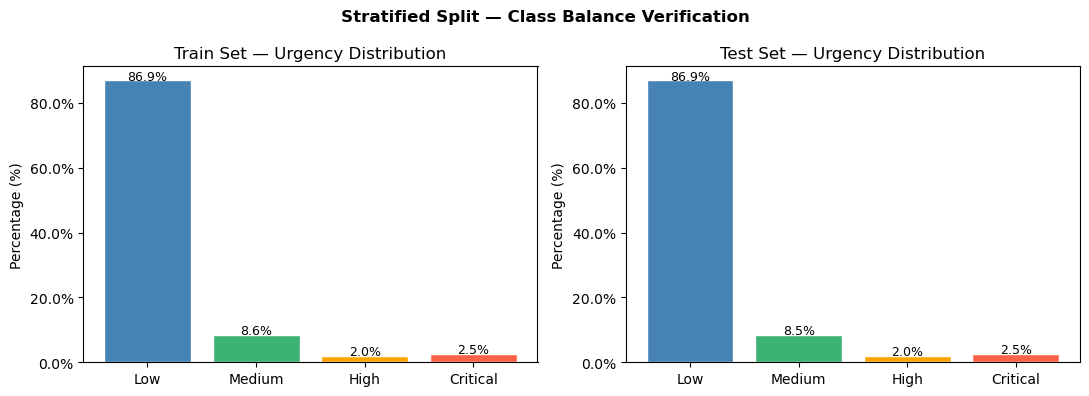

In [6]:
train_df = pd.read_parquet(f'{BASE}/phase1_train.parquet')
test_df  = pd.read_parquet(f'{BASE}/phase1_test.parquet')

print(f'Train rows : {len(train_df):,}')
print(f'Test rows  : {len(test_df):,}')
print(f'Split ratio: {len(train_df)/(len(train_df)+len(test_df)):.0%} / {len(test_df)/(len(train_df)+len(test_df)):.0%}')

train_dist = train_df[TARGET].value_counts(normalize=True).sort_index() * 100
test_dist  = test_df[TARGET].value_counts(normalize=True).sort_index() * 100

print('\nClass distribution (%):')
print(f'{"Label":<12} {"Train":>8} {"Test":>8}')
for i, label in enumerate(LABELS):
    print(f'{label:<12} {train_dist.get(i, 0):>7.1f}% {test_dist.get(i, 0):>7.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x     = np.arange(len(LABELS))
width = 0.35

for ax, (name, dist) in zip(axes, [('Train', train_dist), ('Test', test_dist)]):
    bars = ax.bar(LABELS,
                  [dist.get(i, 0) for i in range(4)],
                  color=COLORS, edgecolor='white')
    ax.set_title(f'{name} Set — Urgency Distribution')
    ax.set_ylabel('Percentage (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    for bar, val in zip(bars, [dist.get(i, 0) for i in range(4)]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Stratified Split — Class Balance Verification', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Distributions After Scaling

StandardScaler centres each continuous feature to mean=0, std=1. Verify that the training features are correctly scaled and test distributions match.

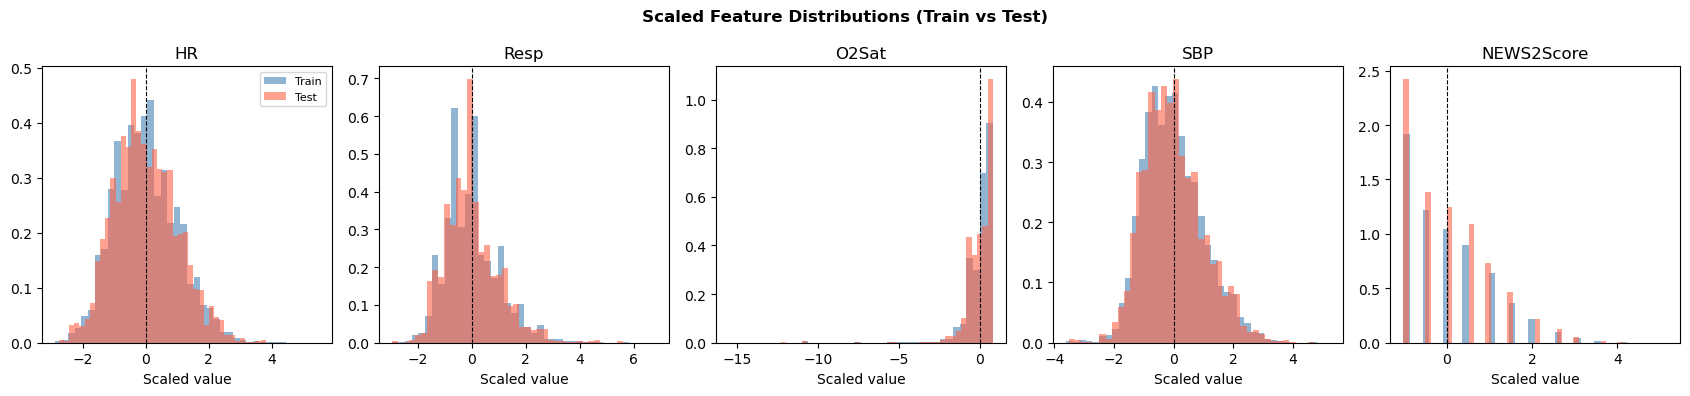

Train feature stats (should be ~mean=0, std=1 for continuous):
       HR  O2Sat  Temp  SBP  MAP  DBP  Resp  ShockIndex  PulsePressure  NEWS2Score
mean  0.0    0.0  -0.0 -0.0 -0.0  0.0   0.0         0.0           -0.0        -0.0
std   1.0    1.0   1.0  1.0  1.0  1.0   1.0         1.0            1.0         1.0


In [7]:
continuous = config['features']['continuous']
plot_cols  = ['HR', 'Resp', 'O2Sat', 'SBP', 'NEWS2Score']

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

for ax, col in zip(axes, plot_cols):
    train_vals = train_df[col].dropna()
    test_vals  = test_df[col].dropna()
    ax.hist(train_vals, bins=40, alpha=0.6, density=True,
            color='steelblue', label='Train')
    ax.hist(test_vals,  bins=40, alpha=0.6, density=True,
            color='tomato', label='Test')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('Scaled value')
    if col == 'HR':
        ax.legend(fontsize=8)

plt.suptitle('Scaled Feature Distributions (Train vs Test)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Train feature stats (should be ~mean=0, std=1 for continuous):')
print(train_df[continuous].describe().loc[['mean', 'std']].round(3).to_string())

## 7. Class Weights

Computed in `preprocessing.py` and passed to all models. Inversely proportional to class frequency — rare classes get higher weights so the model is penalised more for missing them.

Class weights:
  Class 0 (Low       ) count: 13,501  weight: 0.2877
  Class 1 (Medium    ) count:  1,329  weight: 2.9231
  Class 2 (High      ) count:    314  weight: 12.3718
  Class 3 (Critical  ) count:    395  weight: 9.8348


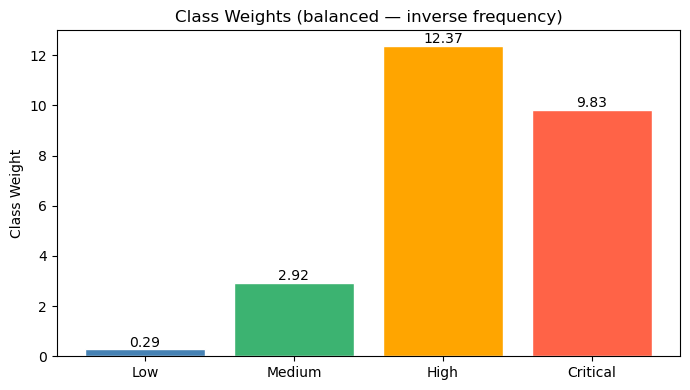


High/Critical get large weights (~10-12x) to compensate for rarity.
This ensures the model is penalised heavily for missing these cases.


In [8]:
from src.preprocessing import compute_class_weights

y_train      = train_df[TARGET]
class_weights = compute_class_weights(y_train)

print('Class weights:')
for cls, weight in class_weights.items():
    label = LABELS[cls]
    count = (y_train == cls).sum()
    print(f'  Class {cls} ({label:<10}) count: {count:>6,}  weight: {weight:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(LABELS,
       [class_weights[i] for i in range(4)],
       color=COLORS, edgecolor='white')
ax.set_ylabel('Class Weight')
ax.set_title('Class Weights (balanced — inverse frequency)')
for bar, val in zip(ax.patches, [class_weights[i] for i in range(4)]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nHigh/Critical get large weights (~10-12x) to compensate for rarity.')
print('This ensures the model is penalised heavily for missing these cases.')

## 8. Final Data Quality Check

In [9]:
print('=== Final Data Quality Check ===')
for name, df_check in [('Train', train_df), ('Test', test_df)]:
    nan_count = df_check[FEATURES].isna().sum().sum()
    status    = '[OK]' if nan_count == 0 else '[WARN]'
    print(f'  {status} {name} set — NaN count in features: {nan_count}')

print(f'\n  Train shape : {train_df.shape}')
print(f'  Test shape  : {test_df.shape}')
print(f'  Features    : {len(FEATURES)}')
print(f'  Target      : {TARGET} (0=Low, 1=Medium, 2=High, 3=Critical)')
print('\n  Data is model-ready. Proceed to 03_model_training.ipynb.')

=== Final Data Quality Check ===
  [OK] Train set — NaN count in features: 0
  [OK] Test set — NaN count in features: 0

  Train shape : (15539, 16)
  Test shape  : (3885, 16)
  Features    : 14
  Target      : UrgencyLevel (0=Low, 1=Medium, 2=High, 3=Critical)

  Data is model-ready. Proceed to 03_model_training.ipynb.
